In [1]:
# Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
plt.style.use('default')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [2]:
# Load data
url = "https://raw.githubusercontent.com/diplomadoequipo908-a11y/Proyecto-modulo-5/main/dataset.csv"
raw = pd.read_csv(url)
raw = raw.drop(columns=['Unnamed: 0'])
# Drop duplicates on track_id keep unique tracks.
df = raw.drop_duplicates(subset='track_id').copy().reset_index(drop=True)
print('Raw data:',raw.shape)
print('Unique tracks data:',df.shape)
df.describe()

Raw data: (114000, 20)
Unique tracks data: (89741, 20)


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,89741.000000,8.974100e+04,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000,89741.000000
mean,33.198438,2.291418e+05,0.562166,0.634458,5.283549,-8.499004,0.636966,0.087442,0.328289,0.173413,0.216970,0.469477,122.058316,3.897427
std,20.580824,1.129477e+05,0.176691,0.256605,3.559897,5.221490,0.480877,0.113277,0.338321,0.323848,0.194884,0.262864,30.117532,0.453435
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,1.730400e+05,0.450000,0.457000,2.000000,-10.322000,0.000000,0.036000,0.017100,0.000000,0.098200,0.249000,99.264000,4.000000
50%,33.000000,2.132930e+05,0.576000,0.676000,5.000000,-7.185000,1.000000,0.048900,0.188000,0.000058,0.132000,0.457000,122.013000,4.000000
75%,49.000000,2.642930e+05,0.692000,0.853000,8.000000,-5.108000,1.000000,0.085900,0.625000,0.097600,0.279000,0.682000,140.077000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


### Data Dictionary
| Column | Type | Range | Description |
|---|---|---|---|
| `track_id` | String | — | Unique Spotify URI identifier for the track |
| `artists` | String | — | Performing artist name(s) |
| `album_name` | String | — | Album the track belongs to |
| `track_name` | String | — | Title of the track |
| `popularity` | Integer | 0 – 100 | Spotify popularity score (higher = more popular) |
| `duration_ms` | Integer | 0 – 5.2M | Track duration in milliseconds |
| `explicit` | Boolean | True/False | Whether the track has explicit lyrics |
| `danceability` | Float | 0.0 – 1.0 | How suitable a track is for dancing |
| `energy` | Float | 0.0 – 1.0 | Perceptual measure of intensity and activity |
| `key` | Integer | 0 – 11 | Musical key (0=C, 1=C♯, 2=D … 11=B) |
| `loudness` | Float | -49.5 – 4.5 | Overall loudness in decibels (dB) |
| `mode` | Integer | 0 or 1 | Modality — 1 = Major, 0 = Minor |
| `speechiness` | Float | 0.0 – 1.0 | Presence of spoken words in the track |
| `acousticness` | Float | 0.0 – 1.0 | Confidence the track is acoustic |
| `instrumentalness` | Float | 0.0 – 1.0 | Predicts whether a track has no vocals |
| `liveness` | Float | 0.0 – 1.0 | Detects presence of a live audience |
| `valence` | Float | 0.0 – 1.0 | Musical positiveness conveyed by the track |
| `tempo` | Float | 0 – 243 | Estimated tempo in beats per minute (BPM) |
| `time_signature` | Integer | 0 – 5 | Estimated time signature of the track |
| `track_genre` | String | 114 classes | Genre label assigned to the track |

## Null values

In [3]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)


album_name          1
track_name          1
artists             1
track_id            0
speechiness         0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
loudness            0
mode                0
key                 0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_genre         0
dtype: int64


In [4]:
# Fill null values
for col in ['track_name', 'album_name', 'artists']:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')


# Exploratory Data Analysis
## Popularity distribution

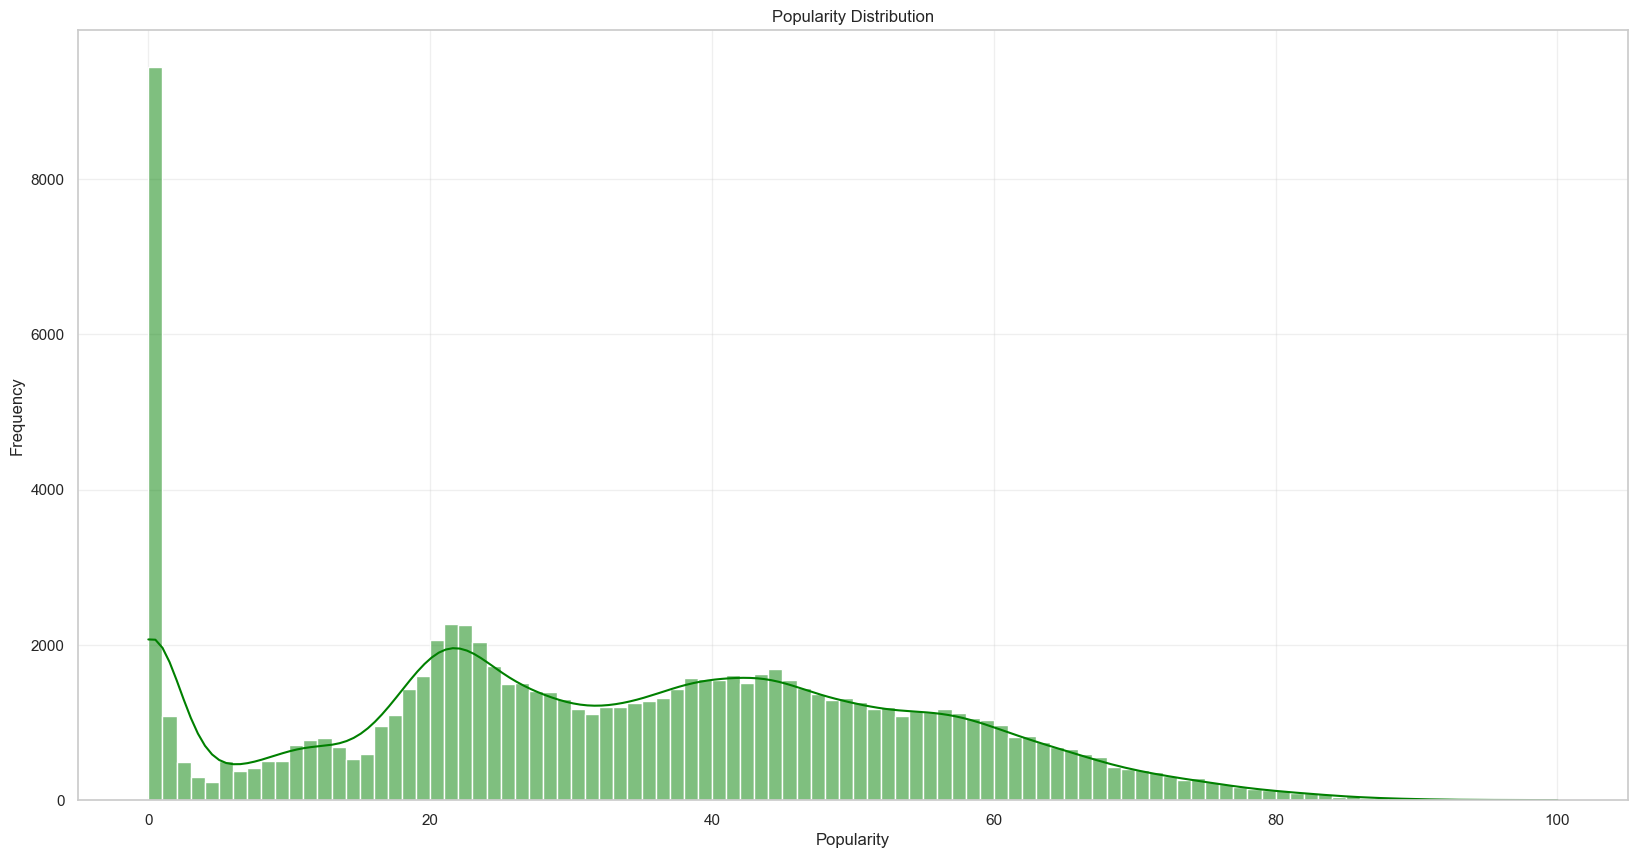

In [5]:
plt.figure(figsize=(20,10))
sns.histplot(df['popularity'], bins=100, kde=True,color='green')
plt.title('Popularity Distribution')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

In [6]:
print(f"Mean: {df['popularity'].mean():.2f}")
print(f"Median: {df['popularity'].median():.2f}")
print(f"Skewness: {skew(df['popularity']):.3f}")

Mean: 33.20
Median: 33.00
Skewness: 0.071


##### Popularity is approximately symmetric and not dominated by extreme values

#### Popular vs unpopular songs

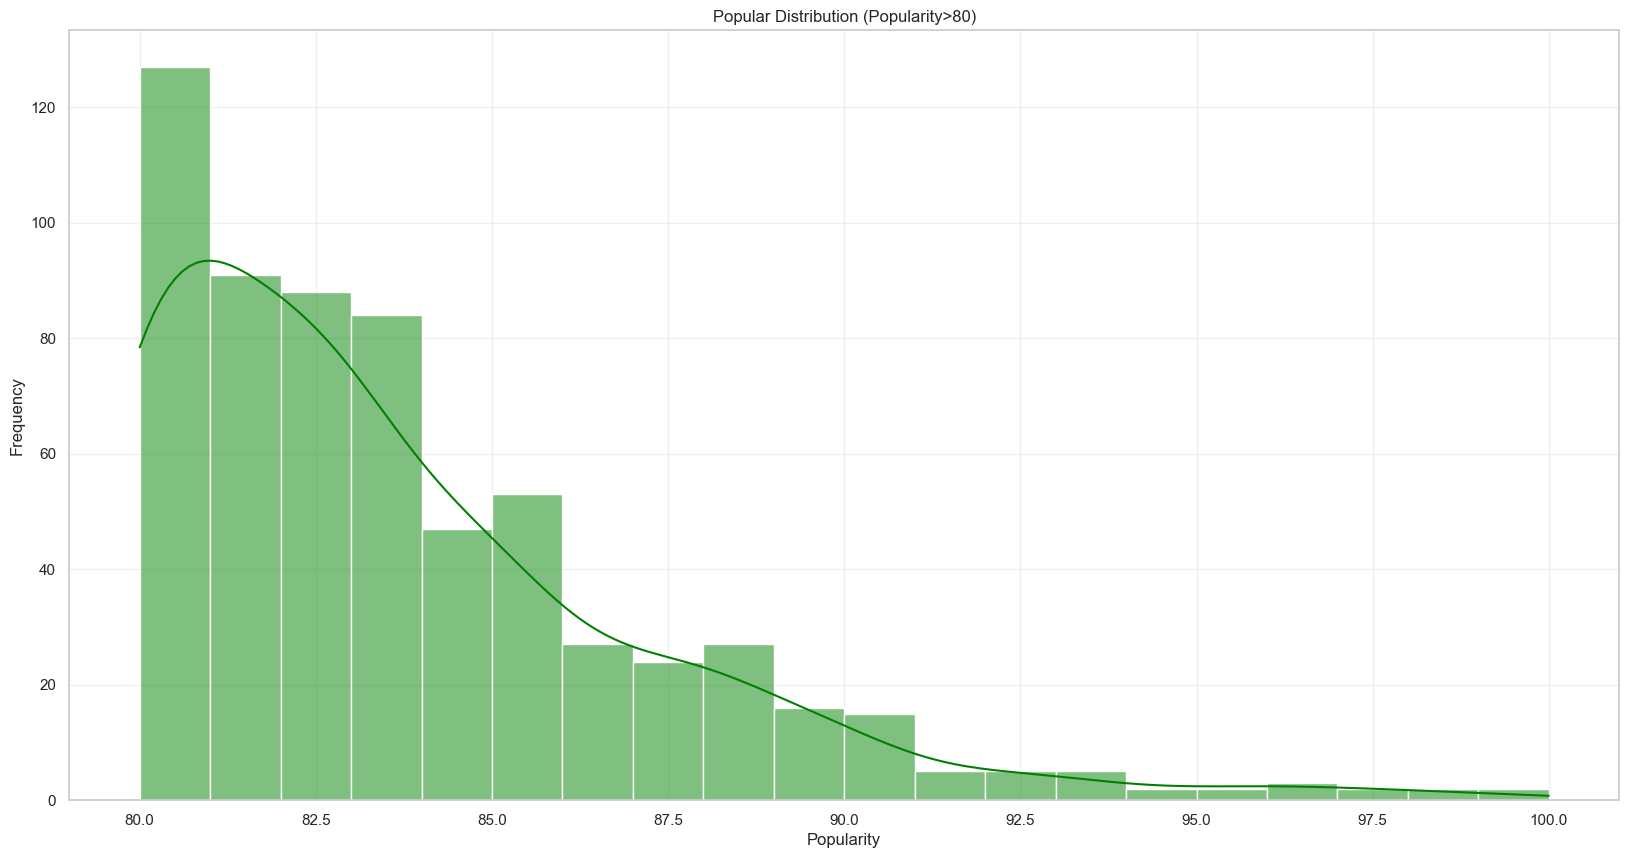

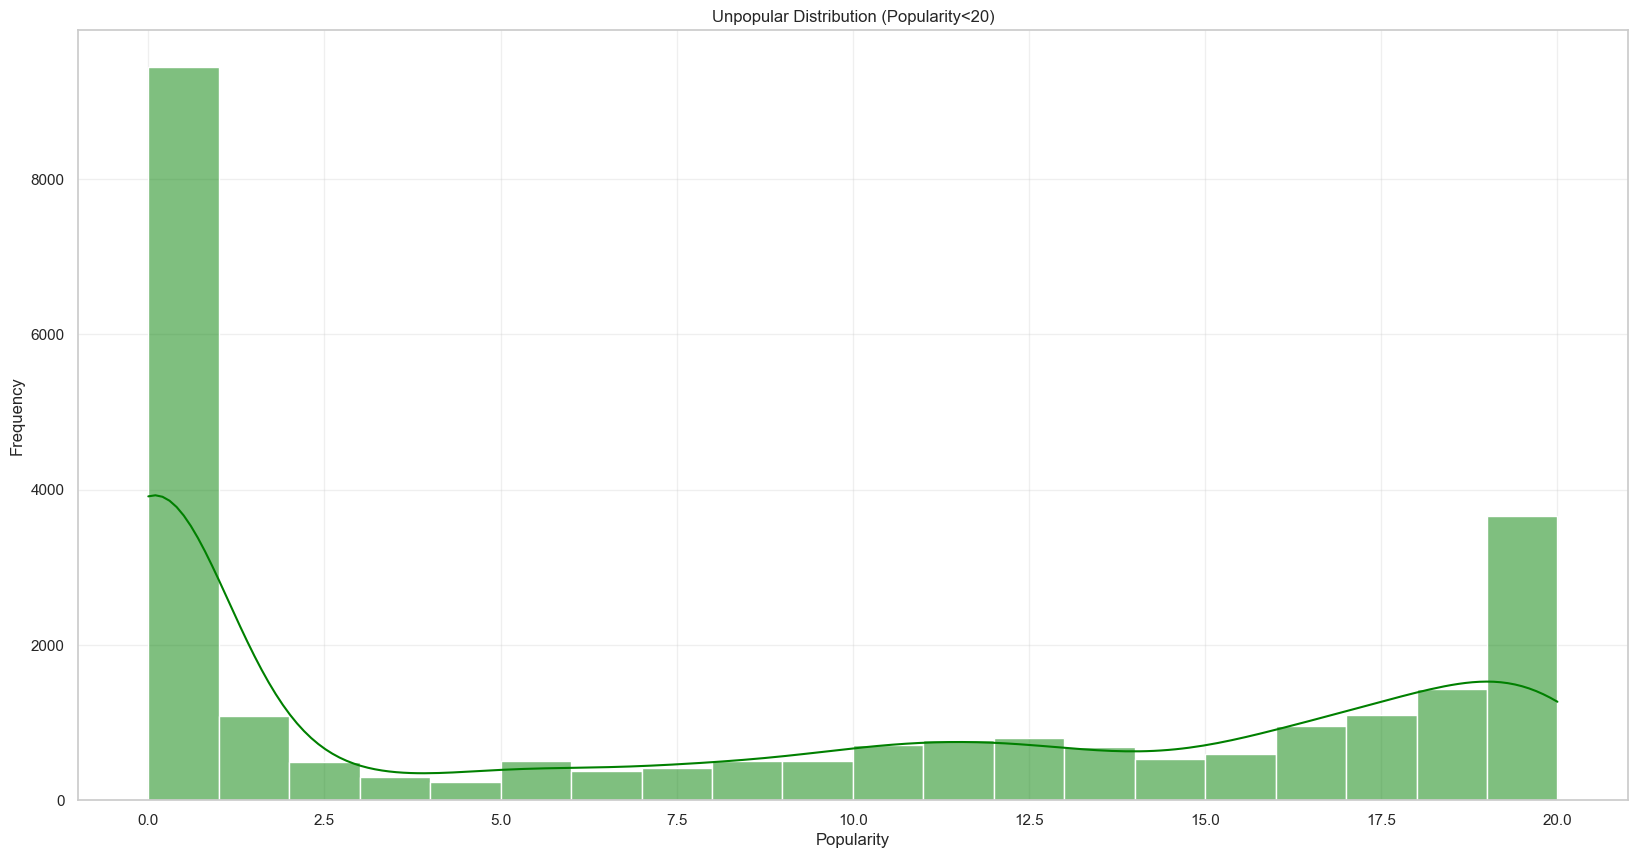

In [7]:
popular = df[df['popularity'] >= 80]

unpopular = df[df['popularity'] <= 20]

plt.figure(figsize=(20,10))
sns.histplot(popular['popularity'], bins=20, kde=True,color='green')
plt.title('Popular Distribution (Popularity>80)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(20,10))
sns.histplot(unpopular['popularity'], bins=20, kde=True,color='green')
plt.title('Unpopular Distribution (Popularity<20)')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)
plt.show()

## Top 20 genres

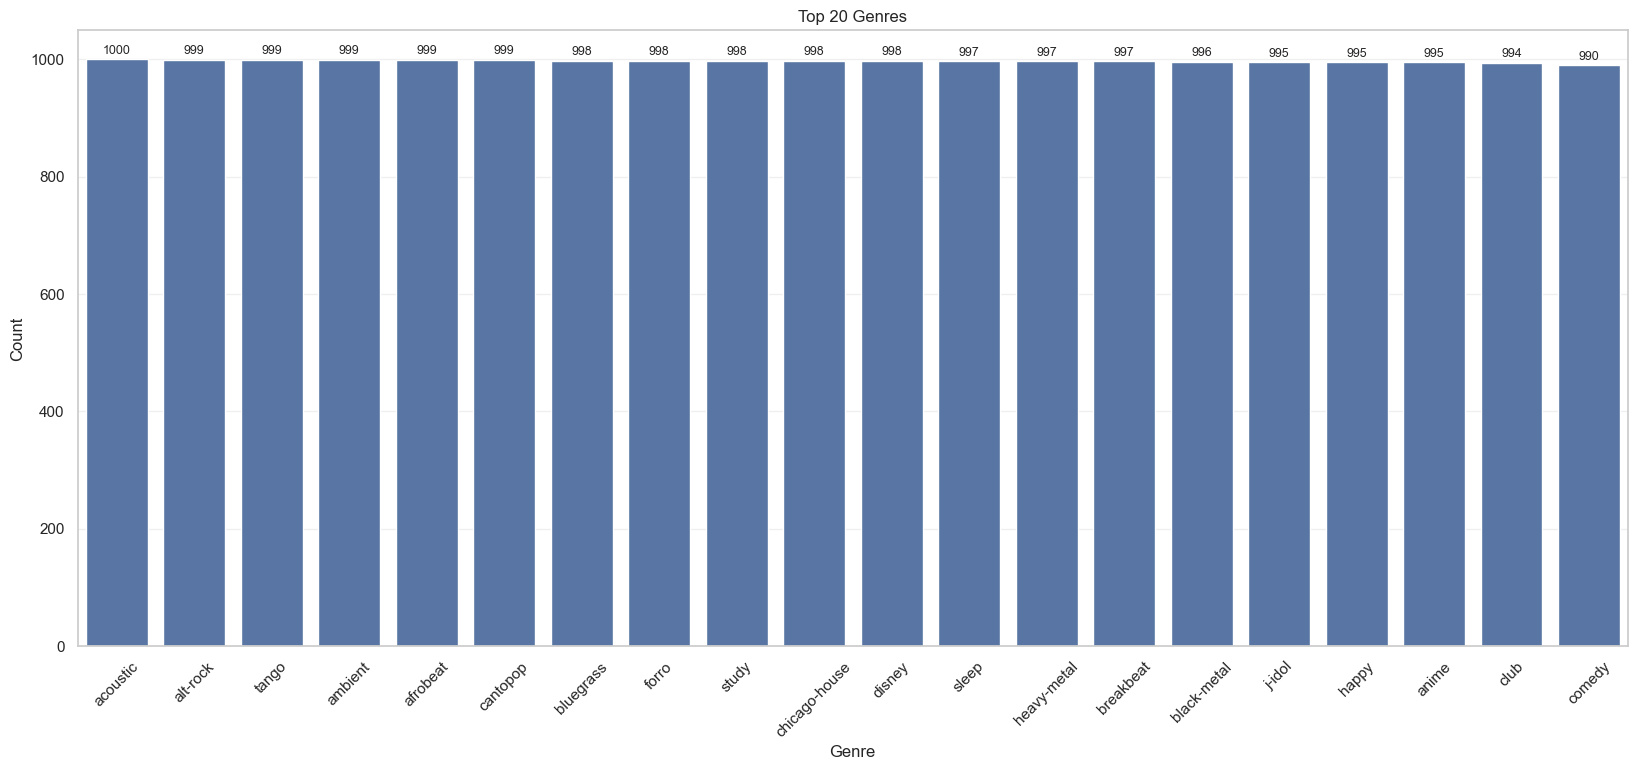

In [8]:
plt.figure(figsize=(20,8))
top_genres = (
    df['track_genre']
    .value_counts()
    .head(20)
)
ax = sns.barplot(x=top_genres.index,y=top_genres.values)

for i, v in enumerate(top_genres.values):
    ax.text(
        i,
        v + 10,
        str(v),
        ha='center',
        fontsize=9
    )

plt.title("Top 20 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

## Average popularity by genres

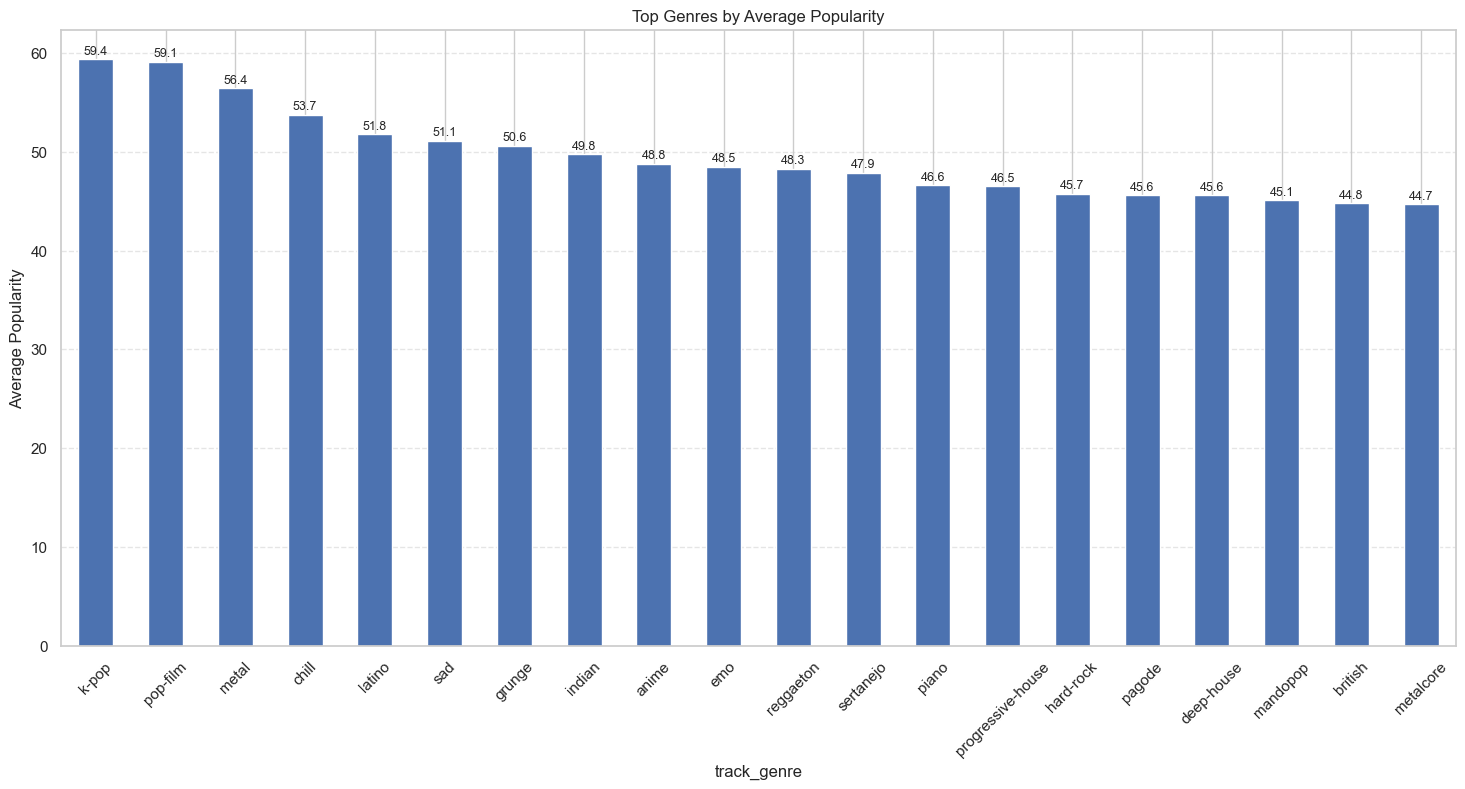

In [9]:
genre_popularity = (
    df.groupby('track_genre')['popularity']
    .mean()
    .sort_values(ascending=False)
)

top_20 = genre_popularity.head(20)

plt.figure(figsize=(18,8))
ax = top_20.plot(kind='bar')
for i, v in enumerate(top_20.values):
    ax.text(
        i,
        v + 0.5,
        f'{v:.1f}',
        ha='center',
        fontsize=9
    )
plt.title("Top Genres by Average Popularity")
plt.ylabel("Average Popularity")
plt.xticks(rotation=45)
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)
plt.show()

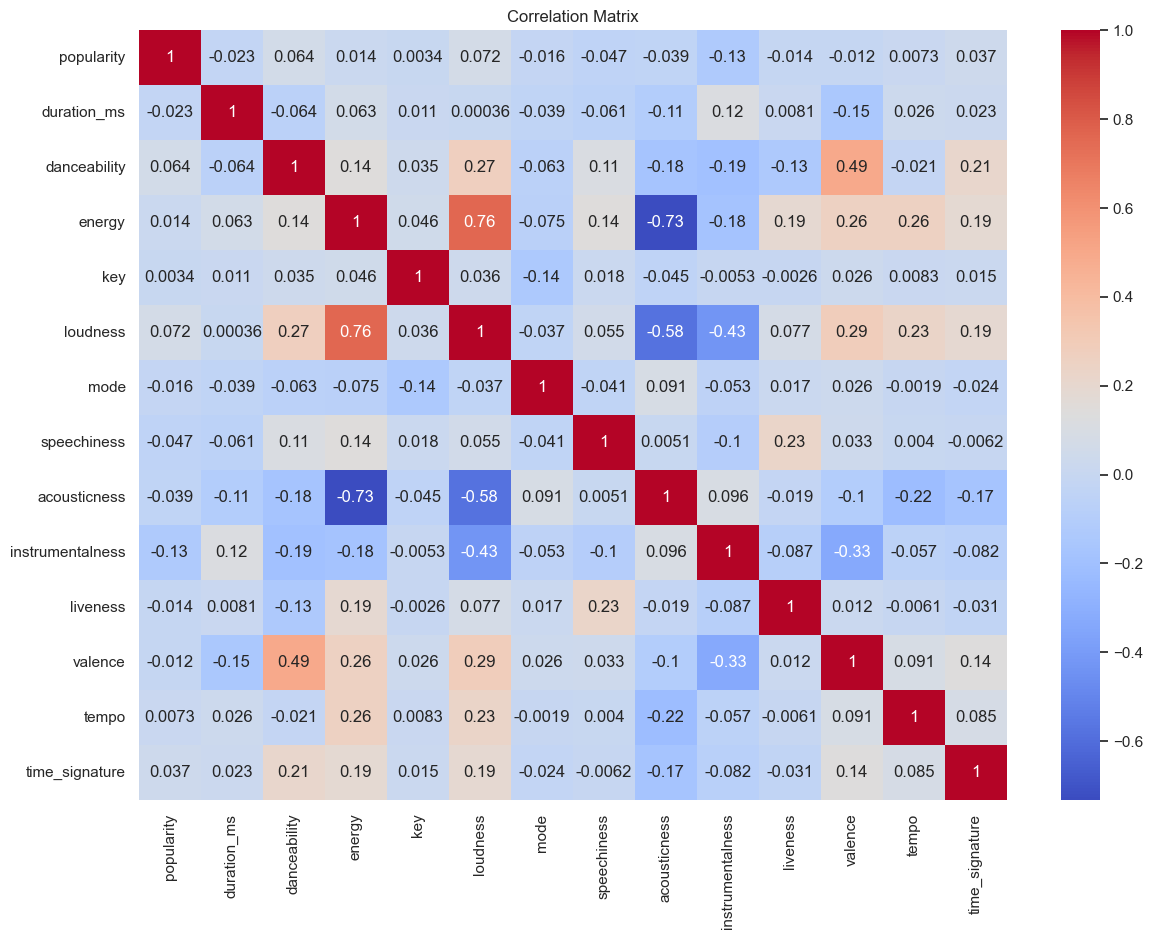

In [10]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title('Correlation Matrix')
plt.show()

## Correlation with Popularity (Linear)

loudness            0.071676
danceability        0.064281
time_signature      0.036893
energy              0.013728
tempo               0.007270
key                 0.003432
valence            -0.011526
liveness           -0.013844
mode               -0.016214
duration_ms        -0.023119
acousticness       -0.038847
speechiness        -0.047081
instrumentalness   -0.127465
Name: popularity, dtype: float64


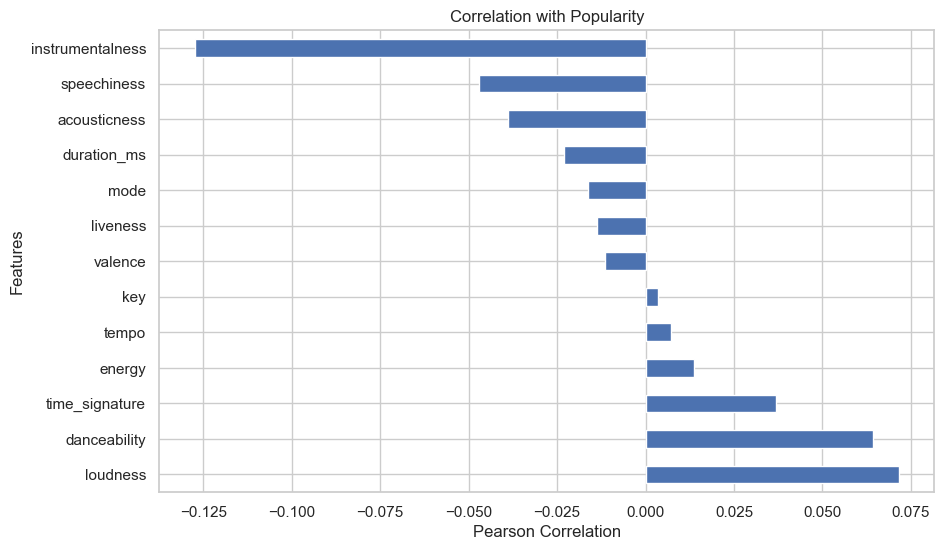

In [11]:
corr_popularity = (
    df.select_dtypes(include=np.number)
      .corr()['popularity']
      .drop('popularity')
      .sort_values(ascending=False)
)

print(corr_popularity)

plt.figure(figsize=(10,6))
corr_popularity.plot(kind='barh')
plt.title("Correlation with Popularity")
plt.xlabel("Pearson Correlation")
plt.ylabel("Features")
plt.show()

##### We can observe that there are no linear audio characteristics correlations with popularity. These findings suggest that popularity is likely driven by complex interactions among multiple audio characteristics and genre-specific effects. Consequently, a nonlinear modeling approach such as a Multilayer Perceptron (MLP) may be better suited to capture these relationships than traditional linear models.

In [12]:
#df['is_niche'] = (df['popularity'] <= 20)

# counts = df['is_niche'].value_counts()

# labels = [
#     'Non-Niche Songs',
#     'Niche Songs'
# ]

# plt.figure(figsize=(8,8))

# plt.pie(
#     counts.values,
#     labels=labels,
#     autopct='%1.1f%%',
#     startangle=90
# )

# plt.title(
#     "Distribution of Niche vs Non-Niche Songs",
#     fontsize=16,
#     fontweight='bold'
# )

# plt.show()


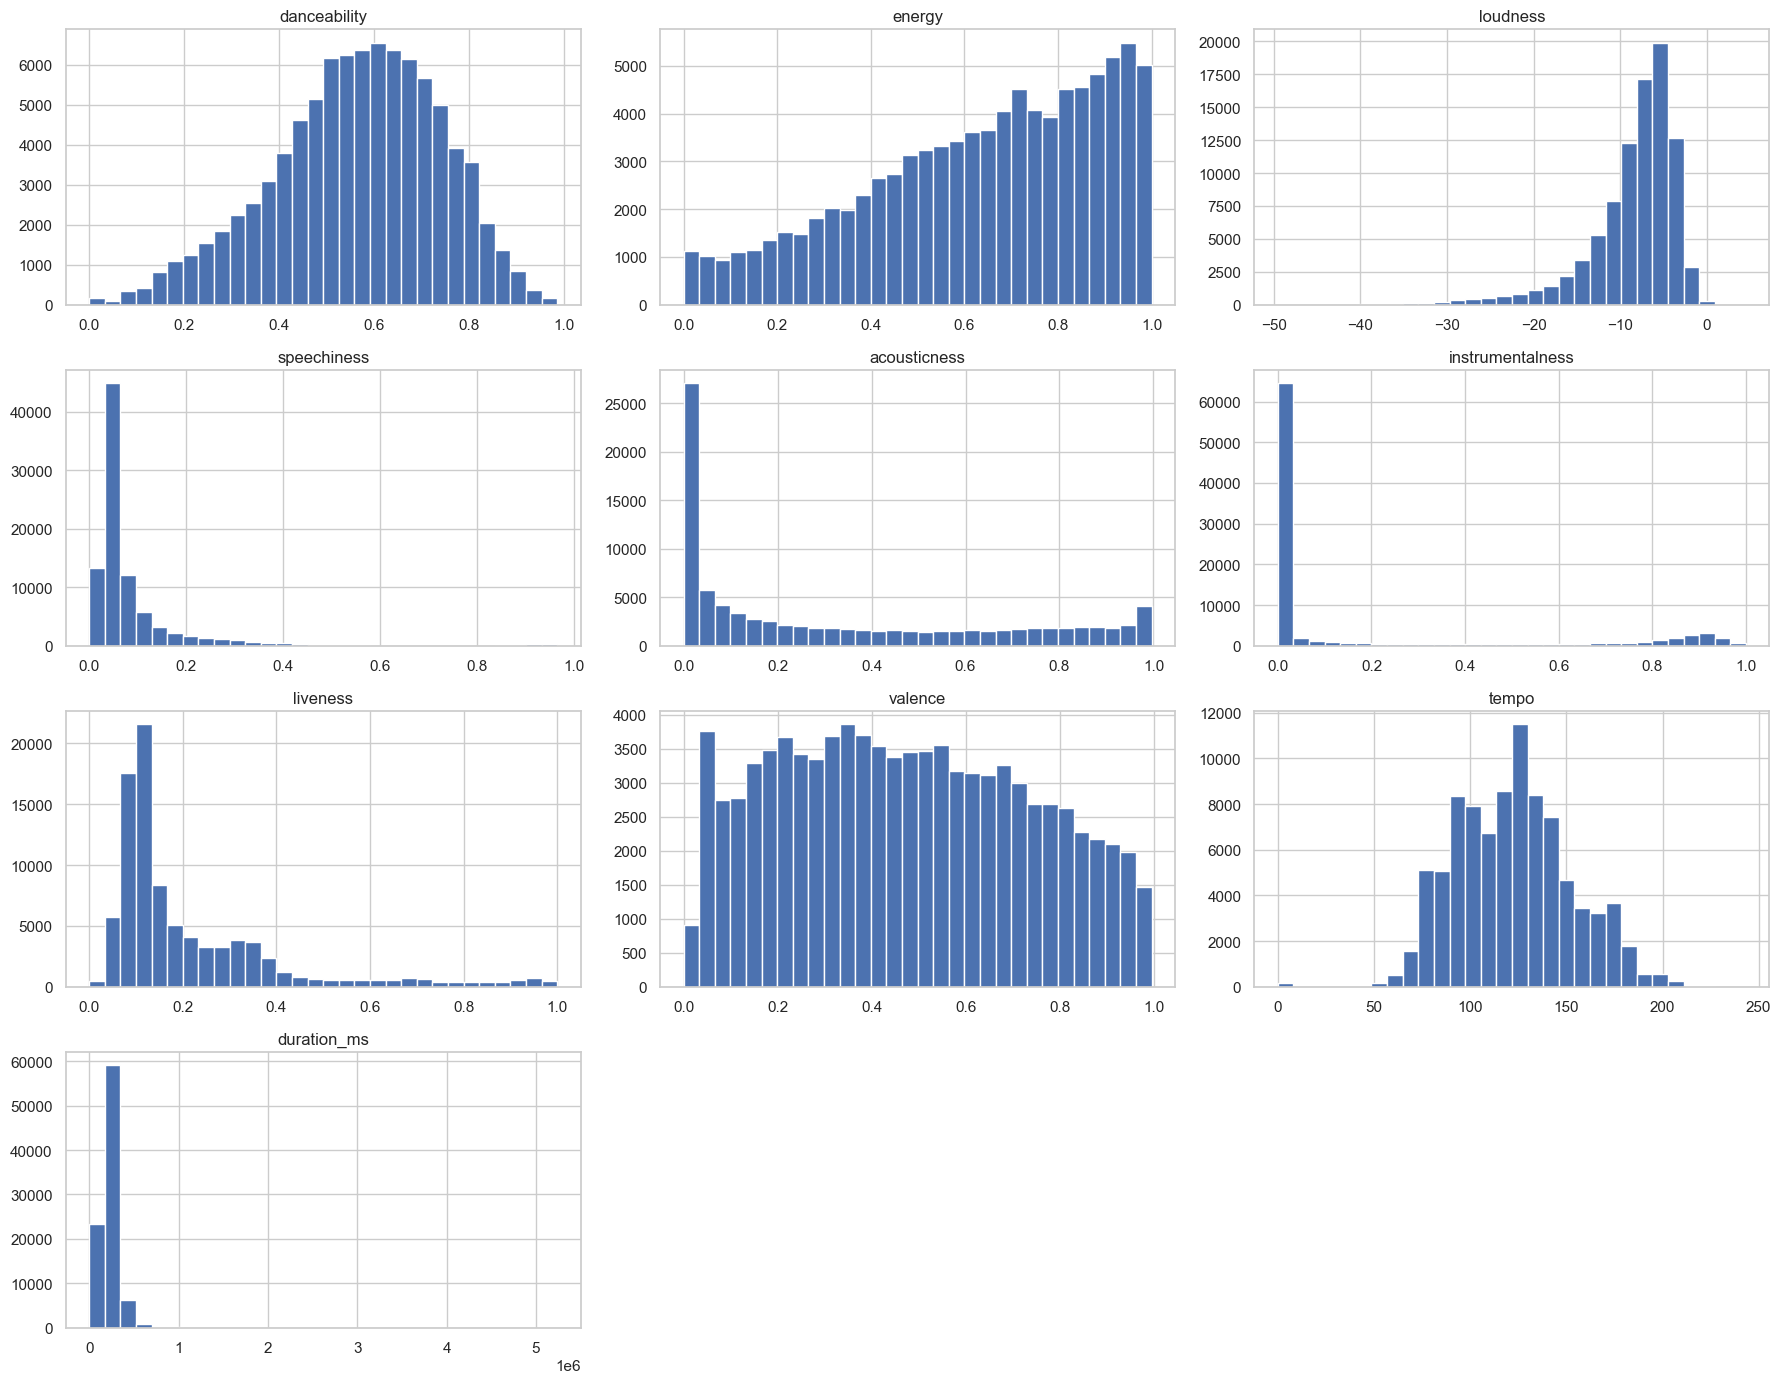

In [13]:
numeric_features = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'duration_ms'
]

df[numeric_features].hist(
    bins=30,
    figsize=(18,14)
)

plt.tight_layout()

plt.show()

## Cleaning

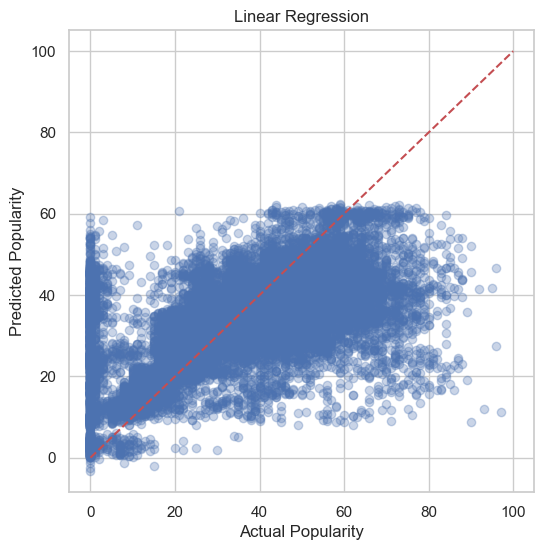

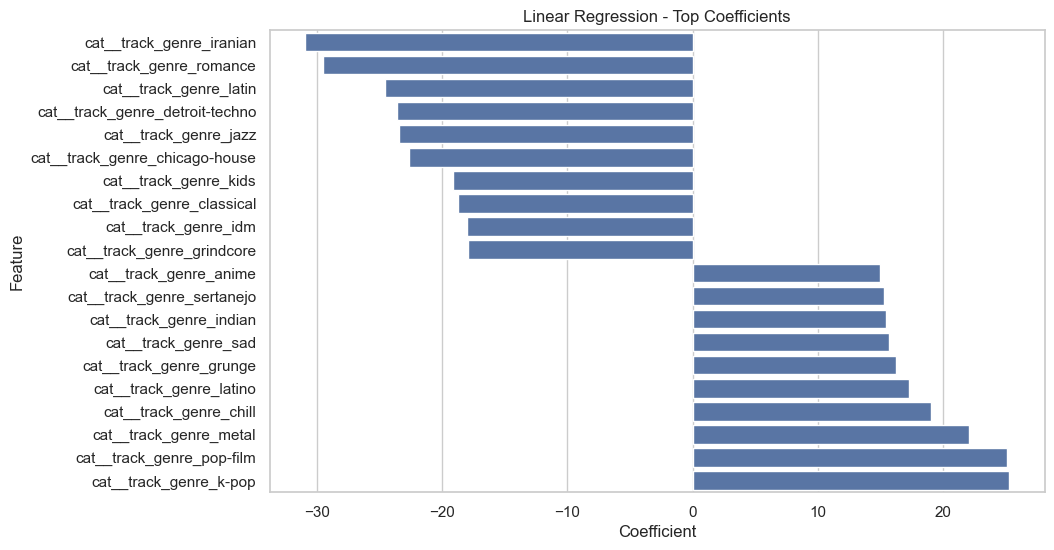


Linear Regression - Top Positive Features
                        Feature  Coefficient
27       cat__track_genre_anime    14.949221
119  cat__track_genre_sertanejo    15.300195
77      cat__track_genre_indian    15.440834
116        cat__track_genre_sad    15.648074
66      cat__track_genre_grunge    16.259112
90      cat__track_genre_latino    17.235392
37       cat__track_genre_chill    19.022759
93       cat__track_genre_metal    22.085045
103   cat__track_genre_pop-film    25.108563
87       cat__track_genre_k-pop    25.283420

Linear Regression - Top Negative Features
                             Feature  Coefficient
81          cat__track_genre_iranian   -30.957353
115         cat__track_genre_romance   -29.532978
89            cat__track_genre_latin   -24.598076
46   cat__track_genre_detroit-techno   -23.631372
86             cat__track_genre_jazz   -23.419571
35    cat__track_genre_chicago-house   -22.643240
88             cat__track_genre_kids   -19.148547
38        cat__trac

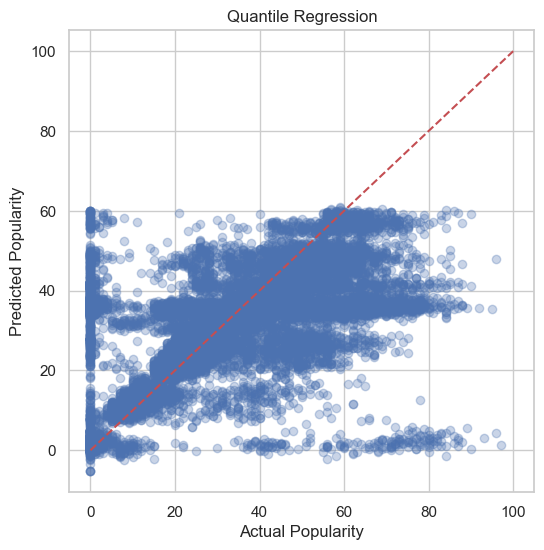

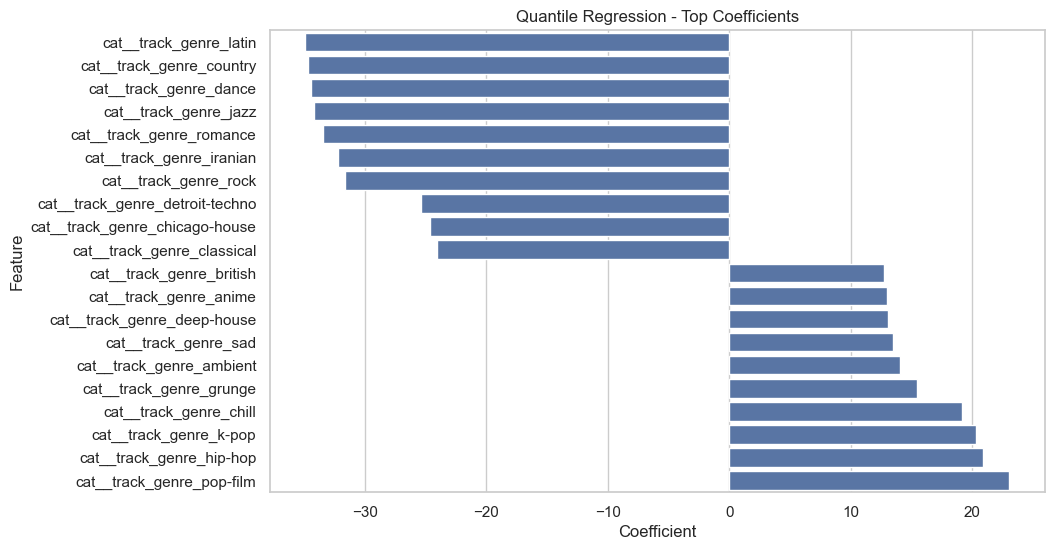


Quantile Regression - Top Positive Features
                         Feature  Coefficient
33      cat__track_genre_british    12.738809
27        cat__track_genre_anime    12.996037
45   cat__track_genre_deep-house    13.079804
116         cat__track_genre_sad    13.490591
26      cat__track_genre_ambient    14.078677
66       cat__track_genre_grunge    15.453648
37        cat__track_genre_chill    19.149013
87        cat__track_genre_k-pop    20.303129
73      cat__track_genre_hip-hop    20.884419
103    cat__track_genre_pop-film    23.049124

Quantile Regression - Top Negative Features
                             Feature  Coefficient
89            cat__track_genre_latin   -34.925582
41          cat__track_genre_country   -34.698176
42            cat__track_genre_dance   -34.406262
86             cat__track_genre_jazz   -34.184571
115         cat__track_genre_romance   -33.461560
81          cat__track_genre_iranian   -32.213080
112            cat__track_genre_rock   -31.607288
46  

In [14]:
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, QuantileRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df_lr = df.drop(columns=[
    'track_id',
    'track_name',
    'album_name',
    'artists',
    'time_signature'
])
# The reason why time_signature was decided to drop is because 89% of data is contained in 4|4, Correlation is negligible. 

df_lr['explicit'] = df_lr['explicit'].astype(int)
df_lr['key'] = df_lr['key'].astype(str)
# Log transform on duration_ms since is heavy skewed 
df_lr['duration_ms'] = np.log1p(df_lr['duration_ms'])

X = df_lr.drop(columns='popularity')
y = df_lr['popularity']



num_features = [
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo'
]

cat_features = ['key', 'track_genre']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
], remainder='passthrough')

# Models 
models = {
    'Linear Regression': LinearRegression(),
    'Quantile Regression': QuantileRegressor(
        quantile=0.5,
        alpha=0.001,
        solver='highs'
    )
}

results = []

for name, model in models.items():

    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    cv_mae = -cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=3,
        scoring='neg_mean_absolute_error'
    ).mean()

    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'CV_MAE': cv_mae
    })

    # Actual vs Predicted
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, preds, alpha=0.3)
    plt.plot([0,100], [0,100], 'r--')
    plt.xlabel('Actual Popularity')
    plt.ylabel('Predicted Popularity')
    plt.title(name)
    plt.show()

    # Coefficients
    feature_names = pipe.named_steps['prep'].get_feature_names_out()

    coef_df = (
        pd.DataFrame({
            'Feature': feature_names,
            'Coefficient': model.coef_
        })
        .sort_values('Coefficient')
    )

    top_coef = pd.concat([
        coef_df.head(10),
        coef_df.tail(10)
    ])

    plt.figure(figsize=(10,6))
    sns.barplot(
        data=top_coef,
        x='Coefficient',
        y='Feature'
    )
    plt.title(f'{name} - Top Coefficients')
    plt.show()

    print(f'\n{name} - Top Positive Features')
    print(coef_df.tail(10))

    print(f'\n{name} - Top Negative Features')
    print(coef_df.head(10))

results = pd.DataFrame(results)

print('\nModel Comparison')
print(results.sort_values('MAE'))